# 💎 Diamond Pricing Engine: a Neural Network Built from Scratch in NumPy

**Goal:** price a diamond instantly and accurately from its specification (carat, cut, colour, clarity and proportions), using **53,770 real diamond sales**.



## 1. The business problem

A diamond retailer lists thousands of stones. Pricing each one by hand is slow and inconsistent, and every pricing mistake costs money:

- **Priced too low:** margin is given away.
- **Priced too high:** the stone sits in inventory, tying up cash.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

SEED = 42
rng = np.random.default_rng(SEED)

# Consistent chart style: one colour per model across the whole notebook
BLUE, ORANGE, INK, INK2, GRID = '#2a78d6', '#eb6834', '#0b0b0b', '#52514e', '#e6e5e1'
ANN_COLOR, BASE_COLOR = BLUE, ORANGE
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.edgecolor': GRID, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.titlesize': 12, 'axes.titleweight': 'bold', 'axes.labelsize': 10,
    'xtick.color': INK2, 'ytick.color': INK2,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'legend.frameon': False, 'font.size': 10, 'axes.axisbelow': True,
})

## 2. The data

**Source:** the *Diamonds* dataset (published with the ggplot2 R package, mirrored in [seaborn-data](https://github.com/mwaskom/seaborn-data)). Each row is one round-cut diamond with its price in US dollars.

| Column | Meaning |
|---|---|
| `carat` | weight (1 carat = 0.2 g) |
| `cut` | Fair < Good < Very Good < Premium < Ideal |
| `color` | J (worst) < I < H < G < F < E < D (best, colourless) |
| `clarity` | I1 (worst) < SI2 < SI1 < VS2 < VS1 < VVS2 < VVS1 < IF (best, flawless) |
| `depth`, `table` | proportions (%) |
| `x`, `y`, `z` | length, width, depth in mm |
| `price` | **target**, USD |

In [2]:
df = pd.read_csv('diamonds.csv')
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [3]:
df.describe().round(2)

,carat,depth,table,price,x,y,z
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.80,61.75,57.46,3932.80,5.73,5.73,3.54
std,0.47,1.43,2.23,3989.44,1.12,1.14,0.71
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5324.25,6.54,6.54,4.04
max,5.01,79.00,95.00,18823.00,10.74,58.90,31.80


### 2.1 Data quality

The summary above shows problems a model would silently learn from:

- some stones have a **dimension of 0 mm** (impossible, so these are missing values),
- a few have **absurd dimensions** (e.g. a 58.9 mm width on a 2-carat stone, which is a data-entry error),
- there are **exact duplicate rows**.

In [4]:
n_start = len(df)
zero_dims  = (df[['x', 'y', 'z']] == 0).any(axis=1)
bad_dims   = (df['y'] > 20) | (df['z'] > 20) | (df['z'] < 1.5)
df = df[~zero_dims & ~bad_dims]
n_after_dims = len(df)
df = df.drop_duplicates().reset_index(drop=True)

print(f'Removed {zero_dims.sum()} rows with a zero dimension')
print(f'Removed {n_start - zero_dims.sum() - n_after_dims} rows with impossible dimensions')
print(f'Removed {n_after_dims - len(df)} exact duplicates')
print(f'Clean dataset: {len(df):,} diamonds')

Removed 20 rows with a zero dimension
Removed 5 rows with impossible dimensions
Removed 145 exact duplicates
Clean dataset: 53,770 diamonds


## 3. Exploring the data:  

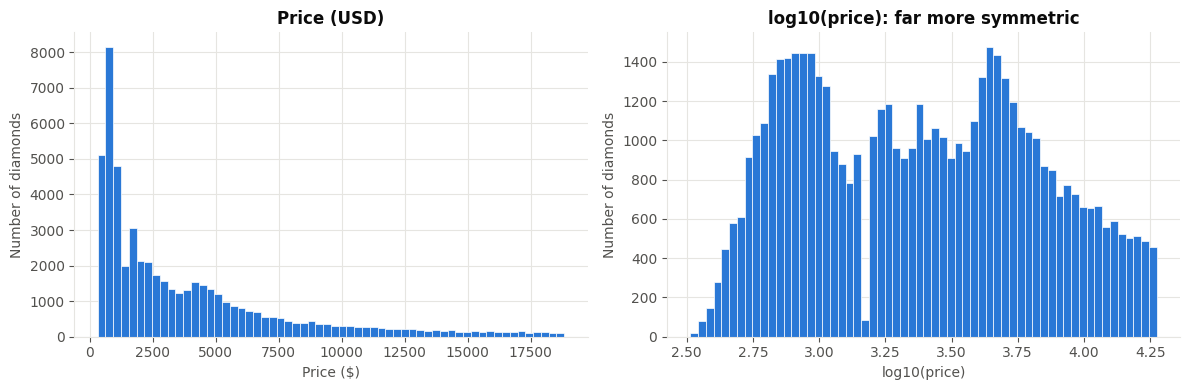

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['price'], bins=60, color=BLUE, edgecolor='white', linewidth=0.5)
axes[0].set_title('Price (USD)')
axes[0].set_xlabel('Price ($)'); axes[0].set_ylabel('Number of diamonds')
axes[1].hist(np.log10(df['price']), bins=60, color=BLUE, edgecolor='white', linewidth=0.5)
axes[1].set_title('log10(price): far more symmetric')
axes[1].set_xlabel('log10(price)'); axes[1].set_ylabel('Number of diamonds')
plt.tight_layout(); plt.show()

## This problem is nonlinear

### 3.1 Prices are heavily skewed

Most stones are cheap, and a few are very expensive. On a log scale the distribution becomes much better behaved, so the model will predict **log(price)** and convert back to dollars at the end.

### 3.2 Price grows much faster than size

A 2-carat stone is not worth twice a 1-carat stone; it is worth several times more. The left chart curves upward. The right chart (both axes on a log scale) shows the relationship is roughly a power law, with visible **jumps at "round" weights** like 1.0, 1.5 and 2.0 carats, where buyers pay a premium.

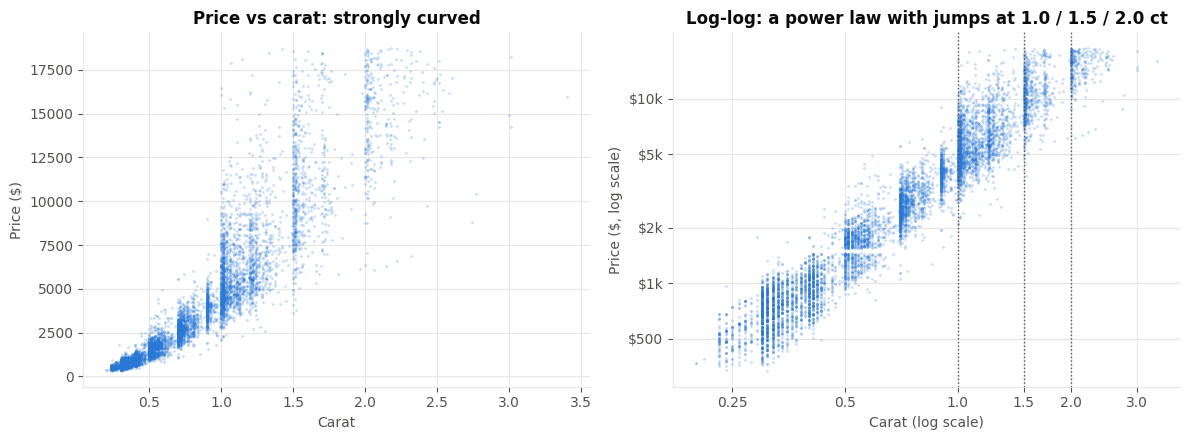

In [6]:
sample = df.sample(8000, random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(sample['carat'], sample['price'], s=4, alpha=0.25, color=BLUE, linewidths=0)
axes[0].set_title('Price vs carat: strongly curved')
axes[0].set_xlabel('Carat'); axes[0].set_ylabel('Price ($)')
axes[1].scatter(sample['carat'], sample['price'], s=4, alpha=0.25, color=BLUE, linewidths=0)
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xticks([0.25, 0.5, 1.0, 1.5, 2.0, 3.0], ['0.25', '0.5', '1.0', '1.5', '2.0', '3.0'])
axes[1].set_yticks([500, 1000, 2000, 5000, 10000], ['$500', '$1k', '$2k', '$5k', '$10k'])
axes[1].minorticks_off()
for c in (1.0, 1.5, 2.0):
    axes[1].axvline(c, color=INK2, linestyle=':', linewidth=1)
axes[1].set_title('Log-log: a power law with jumps at 1.0 / 1.5 / 2.0 ct')
axes[1].set_xlabel('Carat (log scale)'); axes[1].set_ylabel('Price ($, log scale)')
plt.tight_layout(); plt.show()

### 3.3 A trap in the raw averages

Look at the **average price by clarity** (left). Taken at face value it says the two best grades (VVS1 and IF) are among the *cheapest* diamonds, and SI2, one of the worst grades, is the most expensive. That is backwards.

The explanation: better-clarity stones in this data tend to be **smaller**, and size dominates price. When we compare stones of the **same size** (right: 0.9 to 1.1 carat only), clarity behaves as expected, and a flawless (IF) stone is worth almost four times an I1.

**Takeaway for the business:** simple averages and one-variable rules of thumb give wrong answers here. Features interact, so the model has to learn those interactions, which is exactly what a neural network is good at.

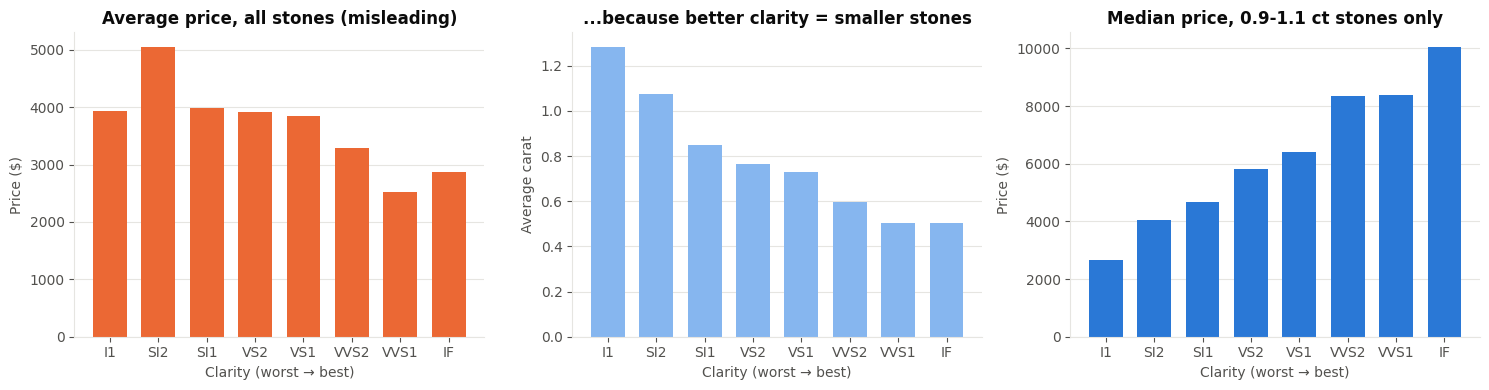

In [7]:
CUT_ORDER     = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
COLOR_ORDER   = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
CLARITY_ORDER = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

avg_all = df.groupby('clarity')['price'].mean().reindex(CLARITY_ORDER)
one_ct  = df[df['carat'].between(0.9, 1.1)]
med_1ct = one_ct.groupby('clarity')['price'].median().reindex(CLARITY_ORDER)
avg_ct  = df.groupby('clarity')['carat'].mean().reindex(CLARITY_ORDER)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(CLARITY_ORDER, avg_all, color=ORANGE, width=0.7)
axes[0].set_title('Average price, all stones (misleading)')
axes[0].set_ylabel('Price ($)')
axes[1].bar(CLARITY_ORDER, avg_ct, color='#86b6ef', width=0.7)
axes[1].set_title('...because better clarity = smaller stones')
axes[1].set_ylabel('Average carat')
axes[2].bar(CLARITY_ORDER, med_1ct, color=BLUE, width=0.7)
axes[2].set_title('Median price, 0.9-1.1 ct stones only')
axes[2].set_ylabel('Price ($)')
for ax in axes:
    ax.set_xlabel('Clarity (worst → best)')
    ax.grid(axis='x', visible=False)
plt.tight_layout(); plt.show()

## 4. Preparing features

- **Encoding:** cut, colour and clarity are *ordered* grades, so each becomes an integer rank (0 = worst). This keeps their natural order and adds only 3 columns.
- **Target:** log(price).
- **Split:** 70% train / 15% validation / 15% test, shuffled with a fixed seed. The **test set is not touched until the final evaluation.**
- **Scaling:** each feature is standardised to mean 0 and standard deviation 1, using statistics from the **training set only**, so no information leaks from validation or test data.

In [8]:
df['cut_rank']     = df['cut'].map({g: i for i, g in enumerate(CUT_ORDER)})
df['color_rank']   = df['color'].map({g: i for i, g in enumerate(COLOR_ORDER)})
df['clarity_rank'] = df['clarity'].map({g: i for i, g in enumerate(CLARITY_ORDER)})

FEATURES = ['carat', 'cut_rank', 'color_rank', 'clarity_rank', 'depth', 'table', 'x', 'y', 'z']
X = df[FEATURES].to_numpy(dtype=float)
y_log = np.log(df['price'].to_numpy(dtype=float)).reshape(-1, 1)
price = df['price'].to_numpy(dtype=float)


def three_way_split(n, val_frac, test_frac, rng):
    idx = rng.permutation(n)
    n_test, n_val = int(n * test_frac), int(n * val_frac)
    return idx[n_test + n_val:], idx[n_test:n_test + n_val], idx[:n_test]

train_idx, val_idx, test_idx = three_way_split(len(X), 0.15, 0.15, rng)
print(f'train: {len(train_idx):,}   validation: {len(val_idx):,}   test: {len(test_idx):,}')


class StandardScaler:
    '''Hand-made standardiser: fit on training data only.'''
    def fit(self, data):
        self.mean_ = data.mean(axis=0)
        self.std_ = data.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self
    def transform(self, data):
        return (data - self.mean_) / self.std_
    def inverse_transform(self, data):
        return data * self.std_ + self.mean_

x_scaler = StandardScaler().fit(X[train_idx])
y_scaler = StandardScaler().fit(y_log[train_idx])

X_train, X_val, X_test = (x_scaler.transform(X[i]) for i in (train_idx, val_idx, test_idx))
y_train, y_val, y_test = (y_scaler.transform(y_log[i]) for i in (train_idx, val_idx, test_idx))
price_train, price_val, price_test = price[train_idx], price[val_idx], price[test_idx]

train: 37,640   validation: 8,065   test: 8,065


### 4.1 Business metrics (also hand-made)

The model is trained on scaled log-prices, but it is **judged in dollars**, with metrics a non-technical reader understands.

In [9]:
def to_dollars(pred_scaled):
    '''Undo the scaling and the log: model output -> price in $.'''
    return np.exp(y_scaler.inverse_transform(pred_scaled)).ravel()


def pricing_report(pred_price, true_price):
    err = pred_price - true_price
    pct = np.abs(err) / true_price
    return {
        'Avg error ($, MAE)':    np.mean(np.abs(err)),
        'RMSE ($)':              np.sqrt(np.mean(err ** 2)),
        'Median % error':        np.median(pct) * 100,
        'Mean % error (MAPE)':   np.mean(pct) * 100,
        'Within ±10% (%)':       np.mean(pct <= 0.10) * 100,
        'R²':                    1 - np.sum(err ** 2) / np.sum((true_price - true_price.mean()) ** 2),
    }

## 5. Baseline: linear regression 

Before building anything complex, I need a benchmark it has to beat. This is ordinary least squares on the same features and the same log-price target, solved directly with `np.linalg.lstsq`. Predicting log-price already gives the linear model a fair chance, since it can capture a power-law trend in carat.

In [10]:
class LinearRegression:
    def fit(self, X, y):
        A = np.c_[np.ones(len(X)), X]                 # add intercept column
        self.coef_ = np.linalg.lstsq(A, y, rcond=None)[0]
        return self
    def predict(self, X):
        return np.c_[np.ones(len(X)), X] @ self.coef_

baseline = LinearRegression().fit(X_train, y_train)
base_val = pricing_report(to_dollars(baseline.predict(X_val)), price_val)
pd.Series(base_val, name='Linear baseline (validation)').round(3)

Avg error ($, MAE)     451.023
RMSE ($)               861.714
Median % error           9.017
Mean % error (MAPE)     11.354
Within ±10% (%)         54.210
R²                       0.951
Name: Linear baseline (validation), dtype: float64

## 6. The neural network

**Architecture:** 9 inputs → 64 → 64 → 32 → 1 output, with ReLU activations on the hidden layers and a linear output (6,913 trainable parameters).

### Activation functions

**ReLU**, applied element-wise:

$$\text{ReLU}(z) = \max(0, z)$$

Without a non-linear activation, stacked layers collapse into one linear map ($W_2(W_1x) = (W_2W_1)x$), so a deep network would be no better than linear regression. ReLU bends the function, and with enough hidden units, sums of ReLUs can approximate any continuous function on a bounded range of inputs (the universal approximation theorem).

The slope of ReLU:

$$\text{ReLU}'(z) = \begin{cases}1 & z > 0\\ 0 & z \le 0\end{cases}$$

`z > 0` gives a True/False array, and `.astype(float)` turns it into 1.0/0.0. At $z = 0$ the derivative is undefined; we use 0.

The **linear** activation on the output layer is $f(z) = z$ with $f'(z) = 1$, because a price can be any real number and must not be cut off at 0.

### The Dense layer

For a batch $A_{in} \in \mathbb{R}^{B \times n_{in}}$, a dense layer with $n_{out}$ neurons computes

$$Z = A_{in}W + b, \qquad A_{out} = f(Z), \qquad W \in \mathbb{R}^{n_{in}\times n_{out}},\; b \in \mathbb{R}^{n_{out}}$$

### Weight initialisation: how big should the starting weights be?

If the starting weights are too large, the signal grows layer after layer and explodes; too small, and it shrinks to nothing. Both make training fail. The goal is to pick $\text{Var}(w)$ so the signal keeps roughly the same size through every layer.

#### Step 1: what one neuron computes

$$z = w_1x_1 + w_2x_2 + \dots + w_{n_{in}}x_{n_{in}} = \sum_{j=1}^{n_{in}} w_j x_j$$

#### Step 2: how big is $z$?

We measure "size" with **variance**. Assume the weights have mean 0 and are independent of the inputs and of each other. Then $\text{Var}(w_j x_j) = \text{Var}(w)\,E[x^2]$, and the variance of a sum of independent terms is the sum of their variances. Since there are $n_{in}$ terms:

$$\text{Var}(z) = n_{in} \cdot \text{Var}(w) \cdot E[x^2]$$

If the inputs also have mean 0, then $E[x^2] = \text{Var}(x)$ and this becomes $\text{Var}(z) = n_{in} \cdot \text{Var}(w) \cdot \text{Var}(x)$.

#### Step 3: choose $\text{Var}(w)$ so the signal keeps the same size (Glorot / Xavier)

For mean-zero inputs we want $\text{Var}(z) = \text{Var}(x)$:

$$n_{in} \cdot \text{Var}(w) = 1 \;\Rightarrow\; \text{Var}(w) = \frac{1}{n_{in}} \quad \text{(forward pass)}$$

The same reasoning for the gradients flowing **backward** through $n_{out}$ neurons gives:

$$\text{Var}(w) = \frac{1}{n_{out}} \quad \text{(backward pass)}$$

Both cannot be true at once (unless $n_{in} = n_{out}$), so Glorot and Bengio (2010) took the **harmonic mean** of the two variances $\frac{1}{n_{in}}$ and $\frac{1}{n_{out}}$:

$$\text{Var}(w) = \frac{2}{n_{in} + n_{out}}$$

#### Step 4: the uniform version, $W \sim U(-a, a)$

$w \sim U(-a, a)$ means every value between $-a$ and $+a$ is equally likely:

$$p(w) = \frac{1}{2a} \quad \text{for } -a \le w \le a \qquad (\text{and } 0 \text{ outside})$$

The mean is 0, so:

$$\text{Var}(w) = \int_{-a}^{a} w^2 \cdot \frac{1}{2a}\, dw = \frac{1}{2a}\left[\frac{w^3}{3}\right]_{-a}^{a} = \frac{1}{2a}\cdot\frac{2a^3}{3} = \frac{a^2}{3}$$

Set this equal to the target from Step 3:

$$\frac{a^2}{3} = \frac{2}{n_{in} + n_{out}} \;\Rightarrow\; a^2 = \frac{6}{n_{in} + n_{out}} \;\Rightarrow\; a = \sqrt{\frac{6}{n_{in} + n_{out}}}$$

So **6 = 3 × 2**: the **3** comes from the uniform distribution and the **2** from averaging the forward and backward conditions. This is the **Glorot (Xavier) uniform** initialisation.

#### Step 5: why this network uses He initialisation instead

Glorot assumes the layer's inputs have mean 0. After a ReLU that is no longer true: ReLU sets every negative value to 0, so it throws away half of the signal. If $z$ is symmetric around 0, exactly half of its values survive:

$$E[\text{ReLU}(z)^2] = \frac{1}{2}\,\text{Var}(z)$$

Putting this into Step 2 for the next layer, $\text{Var}(z_{next}) = n_{in} \cdot \text{Var}(w) \cdot \frac{1}{2}\text{Var}(z)$. To keep the size constant we need $n_{in} \cdot \text{Var}(w) \cdot \frac{1}{2} = 1$:

$$\text{Var}(w) = \frac{2}{n_{in}}$$

This is **He initialisation** (He et al., 2015): the extra factor of **2** makes up for the half that ReLU removes. The code draws from a normal distribution, whose second argument in `rng.normal` is the **standard deviation**, not the variance:

```python
self.W = rng.normal(0.0, np.sqrt(2.0 / n_in), size=(n_in, n_out))   # He init
```

$$W_{jk} \sim \mathcal{N}\!\left(0,\; \frac{2}{n_{in}}\right), \qquad \text{std} = \sqrt{\frac{2}{n_{in}}}$$

(The uniform version of He would be $a = \sqrt{6/n_{in}}$, by the same Step 4 argument.)

#### Numbers for this network

| Layer | $n_{in}$ | $n_{out}$ | $\text{Var}(w) = 2/n_{in}$ | std $= \sqrt{2/n_{in}}$ |
|---|---|---|---|---|
| 1 | 9 | 64 | 0.2222 | 0.4714 |
| 2 | 64 | 64 | 0.0313 | 0.1768 |
| 3 | 64 | 32 | 0.0313 | 0.1768 |
| 4 (output) | 32 | 1 | 0.0625 | 0.2500 |

For layer 1: $\text{std} = \sqrt{2/9} = 0.4714$, and $0.4714^2 = 0.2222 = 2/9\;✓$

### The weight matrix

$W$ is an $n_{in} \times n_{out}$ matrix of independent random draws:

$$W \in \mathbb{R}^{n_{in} \times n_{out}}, \qquad W_{jk} \sim \mathcal{N}\!\left(0, \tfrac{2}{n_{in}}\right) \text{ independently}$$

For layer 1 this is a $9 \times 64$ matrix of 576 random numbers, most of them between about $-0.94$ and $+0.94$ (two standard deviations):

$$W = \begin{bmatrix} W_{1,1} & W_{1,2} & \cdots & W_{1,64} \\ \vdots & \vdots & \ddots & \vdots \\ W_{9,1} & W_{9,2} & \cdots & W_{9,64} \end{bmatrix}$$

Each entry has $E[W_{jk}] = 0$ and $\text{Var}(W_{jk}) = \frac{2}{n_{in}}$. $W_{jk}$ is the weight from **input $j$** to **neuron $k$**, used later in

$$z_k = \sum_{j=1}^{9} x_j W_{jk} + b_k$$

The weights must be **random and different** from each other. If all $W_{jk}$ were equal, every neuron would compute the same $z_k$, receive the same gradient and stay identical forever, so 64 neurons would behave like 1. This is called the **symmetry problem**.

### The bias vector

```python
self.b = np.zeros(n_out)
```

$$b = (b_1, b_2, \dots, b_{64}) = (0, 0, \dots, 0) \in \mathbb{R}^{n_{out}}$$

One bias per neuron, all starting at 0. This is safe because the random $W$ already breaks the symmetry. At the start,

$$z_k = \sum_j x_j W_{jk}$$

is a sum with mean 0 and controlled variance, which is exactly what Steps 1–5 were designed for. (Zero biases are also why the gradient check below temporarily uses small random biases: with $b = 0$, a ReLU input can land exactly on 0, where the derivative is undefined.)

### Forward pass

$$Z = A_{in} W + b, \qquad A_{out} = f(Z)$$

The core formula for every sample $i$ and neuron $k$:

$$Z_{ik} = \sum_{j=1}^{n_{in}} A_{ij}W_{jk} + b_k$$

`A_in @ self.W` performs all these dot products in one matrix multiplication, with shape $(B, n_{in}) \times (n_{in}, n_{out}) = (B, n_{out})$. `+ self.b` broadcasts the bias vector to every row.

Both $A_{in}$ and $Z$ are cached, because the backward pass needs them: $A_{in}$ for $\partial L/\partial W$, and $Z$ for $f'(Z)$.

### Backward pass (backpropagation)

The layer receives $\frac{\partial L}{\partial A_{out}}$ (shape $B \times n_{out}$) from the layer above. It computes its own gradients, plus the gradient to hand back to the previous layer, all by the **chain rule** $\frac{\partial L}{\partial v} = \frac{\partial L}{\partial u}\frac{\partial u}{\partial v}$.

Summary of the four formulas:

$$\delta = \frac{\partial L}{\partial Z} = \frac{\partial L}{\partial A_{out}} \odot f'(Z), \qquad
\frac{\partial L}{\partial W} = A_{in}^\top \delta, \qquad
\frac{\partial L}{\partial b} = \sum_{rows} \delta, \qquad
\frac{\partial L}{\partial A_{in}} = \delta\, W^\top$$

**1. Through the activation.** Because $A_{out} = f(Z)$ element-wise:

$$\delta \equiv \frac{\partial L}{\partial Z} = \frac{\partial L}{\partial A_{out}} \odot f'(Z)$$

For ReLU, this sets the gradient of inactive neurons ($Z \le 0$) to zero; for the linear output it passes through unchanged.

**2. Weights.** $W_{jk}$ affects $Z_{ik}$ for every sample $i$ with $\frac{\partial Z_{ik}}{\partial W_{jk}} = A_{ij}$, so

$$\frac{\partial L}{\partial W_{jk}} = \sum_{i=1}^{B} A_{ij}\,\delta_{ik} \quad\Longleftrightarrow\quad \frac{\partial L}{\partial W} = A_{in}^\top \delta$$

Shapes: $(n_{in}, B) \times (B, n_{out}) = (n_{in}, n_{out})$, the same as $W$. The sum over the batch happens inside the matrix product.

**3. Bias.** $\frac{\partial Z_{ik}}{\partial b_k} = 1$, so

$$\frac{\partial L}{\partial b_k} = \sum_{i=1}^{B}\delta_{ik}$$

`sum(axis=0)` adds down the batch, giving shape $(n_{out},)$ like $b$.

**4. Gradient for the previous layer.** Each input $A_{ij}$ feeds every neuron $k$ with $\frac{\partial Z_{ik}}{\partial A_{ij}} = W_{jk}$; the multivariable chain rule sums over all these paths:

$$\frac{\partial L}{\partial A_{ij}} = \sum_k \delta_{ik}W_{jk} \quad\Longleftrightarrow\quad \frac{\partial L}{\partial A_{in}} = \delta\, W^\top$$

Shape $(B, n_{out}) \times (n_{out}, n_{in}) = (B, n_{in})$. This is returned to the previous layer as its `dA_out`, which is the "back-propagation" of the error.

These are sums over the batch, not averages. The division by $B$ already happens once, in the gradient of the loss (see below), so it must not be repeated here.

**`params_and_grads()`** gives the optimizer each parameter array together with its gradient, as a list of pairs `[(W, dW), (b, db)]`. The arrays themselves (not copies) are returned, so the optimizer can update them **in place**.

### Loss function: mean squared error

The network predicts the scaled log-price $\hat{y}$. For a batch of $B$ stones:

$$L = \frac{1}{B}\sum_{i=1}^{B} (\hat{y}_i - y_i)^2$$

Derivative with respect to each prediction (power rule; the other terms of the sum don't involve $\hat y_i$):

$$\frac{\partial L}{\partial \hat y_i} = \frac{2}{B}(\hat y_i - y_i)$$

This is where backpropagation starts: this gradient is the `dA` passed into the output layer's backward pass. In the code, `y_true.size` equals $B$ because there is one output column. If a prediction is too high, the gradient is positive, and gradient descent pushes the prediction down.

### Optimiser: Adam

Plain gradient descent does $\theta \leftarrow \theta - \eta\,g$, with the same step size $\eta$ for every parameter. **Adam** adds two things: (1) **momentum**, a running average of gradients that smooths out the noise of small batches, and (2) a **per-parameter step size** based on each gradient's typical magnitude.

**The variables:**
- $t$: the step counter (number of updates so far), needed for the bias correction.
- $m$: the **first moment**, a running average of the gradient. It says which *direction* to move.
- $v$: the **second moment**, a running average of the *squared* gradient. It says how *big* (and how noisy) this parameter's gradients usually are.

**Which parameters.** The optimiser loops over every parameter array: layer $l \in \{0,1,2,3\}$, with $p = 0$ for $W$ and $p = 1$ for $b$. `key = (l, p)` identifies the array, so each one keeps its own $m$ and $v$. All operations below are element-wise, so every one of the 6,913 parameters gets its own individual Adam update.

**First moment** (exponential moving average of the gradient):

$$m_t = \beta_1 m_{t-1} + (1-\beta_1)\,g_t$$

Unrolled, $m_t = (1-\beta_1)\sum_{s\le t}\beta_1^{t-s}g_s$: recent gradients count most and old ones fade geometrically. Consistent directions build up and random noise cancels out (momentum). `.get(key, 0)` returns 0 at the first step.

**Second moment** (moving average of the squared gradient):

$$v_t = \beta_2 v_{t-1} + (1-\beta_2)\,g_t^2$$

$\sqrt{v_t}$ estimates the typical magnitude (root mean square) of this parameter's gradient.

**Bias correction.** Because $m_0 = v_0 = 0$, the early averages are pulled towards 0. The weights $(1-\beta)\sum_{s=1}^{t}\beta^{t-s}$ form a geometric series summing to $1 - \beta^t$, so $\mathbb{E}[m_t] \approx (1-\beta_1^t)\,\mathbb{E}[g]$. Dividing corrects this:

$$\hat m_t = \frac{m_t}{1-\beta_1^t}, \qquad \hat v_t = \frac{v_t}{1-\beta_2^t}$$

At $t = 1$: $\hat m_1 = \frac{0.1\,g_1}{0.1} = g_1$ exactly, and likewise $\hat v_1 = g_1^2$. For large $t$, $\beta^t \to 0$ and the correction vanishes.

**The update:**

$$\theta_t = \theta_{t-1} - \eta\,\frac{\hat m_t}{\sqrt{\hat v_t}+\varepsilon}$$

with learning rate $\eta = 0.001$, $\beta_1 = 0.9$, $\beta_2 = 0.999$ and $\varepsilon = 10^{-8}$ (which prevents division by zero).

$\hat m/\sqrt{\hat v}$ is about $\pm1$ when the gradient direction is consistent and smaller when it is noisy, so each parameter usually moves by **about $\eta$ or less** per step, whatever the scale of its raw gradient. (On the very first step, $\hat m_1/\sqrt{\hat v_1} = g_1/|g_1| = \pm 1$, so every parameter moves by exactly $\eta$. The Adam paper shows that with these default settings a step can reach roughly $3\eta$ in rare cases.) This fixed step size is also why the target must be scaled: if the output had to climb to a raw price like \$44,000 in steps of about 0.001, training would take forever.

In [11]:
def relu(z):            return np.maximum(0, z)
def relu_grad(z):       return (z > 0).astype(float)
def identity(z):        return z
def identity_grad(z):   return np.ones_like(z)

ACTIVATIONS = {'relu': (relu, relu_grad), 'linear': (identity, identity_grad)}


class Dense:
    '''Fully connected layer: A_out = activation(A_in @ W + b).'''
    def __init__(self, n_in, n_out, activation, rng):
        self.activation = activation
        self.act, self.act_grad = ACTIVATIONS[activation]
        self.W = rng.normal(0.0, np.sqrt(6.0 / n_in), size=(n_in, n_out))   # He init
        self.b = np.zeros(n_out)

    def forward(self, A_in):
        self.A_in = A_in
        self.Z = A_in @ self.W + self.b
        return self.act(self.Z)

    def backward(self, dA_out):
        dZ = dA_out * self.act_grad(self.Z)
        self.dW = self.A_in.T @ dZ
        self.db = dZ.sum(axis=0)
        return dZ @ self.W.T

    def params_and_grads(self):
        return [(self.W, self.dW), (self.b, self.db)]


class Sequential:
    def __init__(self, layers=None):
        self.layers = layers or []

    def add(self, layer):
        self.layers.append(layer)

    def predict(self, X):
        A = X
        for layer in self.layers:
            A = layer.forward(A)
        return A

    def backward(self, dA):
        for layer in reversed(self.layers):
            dA = layer.backward(dA)

    def get_weights(self):
        return [(l.W.copy(), l.b.copy()) for l in self.layers]

    def set_weights(self, weights):
        for layer, (W, b) in zip(self.layers, weights):
            layer.W, layer.b = W.copy(), b.copy()

    def summary(self):
        total = 0
        print(f"{'Layer':<10}{'Output shape':<15}{'Activation':<12}{'Params':>8}")
        for i, l in enumerate(self.layers):
            n = l.W.size + l.b.size
            total += n
            print(f"{'dense_' + str(i):<10}{str((None, l.W.shape[1])):<15}{l.activation:<12}{n:>8,}")
        print(f'Total trainable parameters: {total:,}')


def mse_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)

def mse_grad(y_pred, y_true):
    return 2 * (y_pred - y_true) / y_true.size


class Adam:
    def __init__(self, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr, self.beta1, self.beta2, self.eps = lr, beta1, beta2, eps
        self.t, self.m, self.v = 0, {}, {}

    def step(self, layers):
        self.t += 1
        for l, layer in enumerate(layers):
            for p, (param, grad) in enumerate(layer.params_and_grads()):
                key = (l, p)
                self.m[key] = self.beta1 * self.m.get(key, 0) + (1 - self.beta1) * grad
                self.v[key] = self.beta2 * self.v.get(key, 0) + (1 - self.beta2) * grad ** 2
                m_hat = self.m[key] / (1 - self.beta1 ** self.t)
                v_hat = self.v[key] / (1 - self.beta2 ** self.t)
                param -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)   # in-place update

### 6.1 Gradient check: proving the backpropagation is correct

Hand-written backpropagation is easy to get subtly wrong: the model still trains, just badly. To verify it, I compare every analytical gradient with a **numerical estimate** from finite differences:

$$\frac{\partial L}{\partial w} \approx \frac{L(w + \epsilon) - L(w - \epsilon)}{2\epsilon}$$

A relative error around $10^{-7}$ or smaller means the gradients are correct.

*A subtlety:* ReLU has no derivative exactly at 0. With all biases starting at 0, a row where every unit in one layer is switched off feeds an exact 0 into the next layer, right on that kink, and the check reports a false failure. Giving the biases small random values for the check avoids this.

In [12]:
def gradient_check(model, X, y, eps=1e-5):
    model.backward(mse_grad(model.predict(X), y))
    analytic = [g.copy() for layer in model.layers for _, g in layer.params_and_grads()]
    numeric = []
    for layer in model.layers:
        for param, _ in layer.params_and_grads():
            num = np.zeros_like(param)
            it = np.nditer(param, flags=['multi_index'])
            for _ in it:
                i = it.multi_index
                old = param[i]
                param[i] = old + eps; loss_plus  = mse_loss(model.predict(X), y)
                param[i] = old - eps; loss_minus = mse_loss(model.predict(X), y)
                param[i] = old
                num[i] = (loss_plus - loss_minus) / (2 * eps)
            numeric.append(num)
    a = np.concatenate([g.ravel() for g in analytic])
    n = np.concatenate([g.ravel() for g in numeric])
    return np.linalg.norm(a - n) / (np.linalg.norm(a) + np.linalg.norm(n))

check_rng = np.random.default_rng(0)
tiny = Sequential([Dense(9, 6, 'relu', check_rng), Dense(6, 4, 'relu', check_rng), Dense(4, 1, 'linear', check_rng)])
for layer in tiny.layers:
    # Non-zero biases so no ReLU input sits exactly on the kink at 0 (derivative undefined there)
    layer.b = check_rng.normal(0, 0.1, size=layer.b.shape)
rel_err = gradient_check(tiny, X_train[:20], y_train[:20])
print(f'Relative difference, analytic vs numerical gradients: {rel_err:.2e}')
print('PASS: backpropagation is correct' if rel_err < 1e-6 else 'FAIL: check backward()')

Relative difference, analytic vs numerical gradients: 1.89e-11
PASS: backpropagation is correct


### 6.2 Training loop

- **Mini-batches** of 256 stones, reshuffled every epoch.
- **Learning-rate decay:** the step size is cut to 30% at epochs 60 and 120, for finer adjustments late in training.
- **Early stopping:** training stops if validation loss has not improved for 25 epochs, and the **best weights are restored**. This prevents overfitting without needing to guess the right number of epochs.

In [13]:
def fit(model, optimizer, X_tr, y_tr, X_va, y_va, rng, epochs=200, batch_size=256,
        lr_drops=(60, 120), lr_factor=0.3, patience=25, verbose_every=10):
    history = {'loss': [], 'val_loss': []}
    best_val, best_weights, best_epoch, waited = np.inf, None, 0, 0
    for epoch in range(1, epochs + 1):
        if epoch in lr_drops:
            optimizer.lr *= lr_factor
        order = rng.permutation(len(X_tr))
        batch_losses = []
        for start in range(0, len(X_tr), batch_size):
            batch = order[start:start + batch_size]
            y_pred = model.predict(X_tr[batch])
            batch_losses.append(mse_loss(y_pred, y_tr[batch]))
            model.backward(mse_grad(y_pred, y_tr[batch]))
            optimizer.step(model.layers)
        history['loss'].append(np.mean(batch_losses))
        history['val_loss'].append(mse_loss(model.predict(X_va), y_va))

        if history['val_loss'][-1] < best_val - 1e-6:
            best_val, best_weights, best_epoch, waited = history['val_loss'][-1], model.get_weights(), epoch, 0
        else:
            waited += 1
        if epoch % verbose_every == 0 or epoch == 1:
            print(f"Epoch {epoch:>3}/{epochs} - loss: {history['loss'][-1]:.5f} - val_loss: {history['val_loss'][-1]:.5f}")
        if waited >= patience:
            print(f'Early stopping at epoch {epoch}.')
            break
    model.set_weights(best_weights)
    print(f'Restored best weights from epoch {best_epoch} (val_loss {best_val:.5f}).')
    history['best_epoch'] = best_epoch
    return history

In [14]:
model_rng = np.random.default_rng(0)
model = Sequential()
model.add(Dense(len(FEATURES), 64, 'relu', model_rng))
model.add(Dense(64, 64, 'relu', model_rng))
model.add(Dense(64, 32, 'relu', model_rng))
model.add(Dense(32, 1, 'linear', model_rng))
model.summary()

Layer     Output shape   Activation    Params
dense_0   (None, 64)     relu             640
dense_1   (None, 64)     relu           4,160
dense_2   (None, 32)     relu           2,080
dense_3   (None, 1)      linear            33
Total trainable parameters: 6,913


In [15]:
t0 = time.time()
history = fit(model, Adam(lr=1e-3), X_train, y_train, X_val, y_val, rng=model_rng)
print(f'Training time: {time.time() - t0:.1f} s on a CPU, pure NumPy')

Epoch   1/200 - loss: 2.90274 - val_loss: 0.90260
Epoch  10/200 - loss: 0.11249 - val_loss: 0.11131
Epoch  20/200 - loss: 0.04761 - val_loss: 0.05918
Epoch  30/200 - loss: 0.02828 - val_loss: 0.03411
Epoch  40/200 - loss: 0.02181 - val_loss: 0.02428
Epoch  50/200 - loss: 0.01685 - val_loss: 0.01837
Epoch  60/200 - loss: 0.01499 - val_loss: 0.01520
Epoch  70/200 - loss: 0.01299 - val_loss: 0.01495
Epoch  80/200 - loss: 0.01252 - val_loss: 0.01459
Epoch  90/200 - loss: 0.01220 - val_loss: 0.01404
Epoch 100/200 - loss: 0.01176 - val_loss: 0.01551
Epoch 110/200 - loss: 0.01168 - val_loss: 0.01327
Epoch 120/200 - loss: 0.01077 - val_loss: 0.01268
Epoch 130/200 - loss: 0.01066 - val_loss: 0.01260
Epoch 140/200 - loss: 0.01065 - val_loss: 0.01259
Epoch 150/200 - loss: 0.01053 - val_loss: 0.01247
Epoch 160/200 - loss: 0.01045 - val_loss: 0.01256
Epoch 170/200 - loss: 0.01038 - val_loss: 0.01242
Epoch 180/200 - loss: 0.01036 - val_loss: 0.01243
Epoch 190/200 - loss: 0.01034 - val_loss: 0.01243


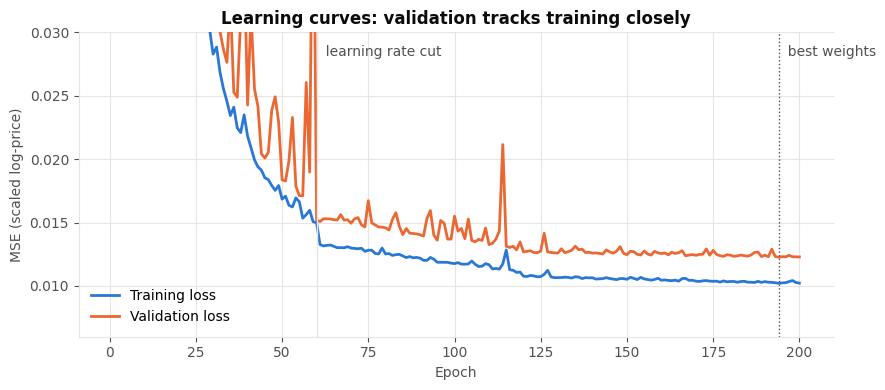

In [16]:
epochs_run = np.arange(1, len(history['loss']) + 1)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs_run, history['loss'], color=BLUE, linewidth=2, label='Training loss')
ax.plot(epochs_run, history['val_loss'], color=ORANGE, linewidth=2, label='Validation loss')
ax.set_ylim(0.006, 0.03)   # epoch 1 (loss ~0.07) is above the frame
ax.axvline(history['best_epoch'], color=INK2, linestyle=':', linewidth=1)
ax.text(history['best_epoch'], 0.029, '  best weights', color=INK2, va='top')
ax.axvline(60, color=GRID, linewidth=1)
ax.text(60, 0.029, '  learning rate cut', color=INK2, va='top')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE (scaled log-price)')
ax.set_title('Learning curves: validation tracks training closely')
ax.legend()
plt.tight_layout(); plt.show()

**Reading the curves:** the validation loss stays close to the training loss the whole way, so the network is not memorising the training stones. The spikes before epoch 60 come from the large early learning rate. After the first learning-rate cut at epoch 60, training settles and both curves flatten. Early stopping then restores the weights from the best validation epoch.

## 7. Results on the held-out test set

This is the first time either model sees the test diamonds. (In the scatter plots, the empty vertical strip near \$1,500 is a known quirk of this dataset: no stones in it are priced between about \$1,450 and \$1,550.)

In [17]:
pred_base_test = to_dollars(baseline.predict(X_test))
pred_ann_test  = to_dollars(model.predict(X_test))

results = pd.DataFrame({
    'Linear baseline': pricing_report(pred_base_test, price_test),
    'Neural network':  pricing_report(pred_ann_test, price_test),
})
results['Improvement'] = [
    f"{(1 - results.iloc[i, 1] / results.iloc[i, 0]) * 100:.0f}% lower" if i < 4 else
    (f"+{results.iloc[i, 1] - results.iloc[i, 0]:.1f} pts" if i == 4 else f"+{results.iloc[i, 1] - results.iloc[i, 0]:.3f}")
    for i in range(len(results))
]
fmt = results.copy()
for col in ['Linear baseline', 'Neural network']:
    fmt[col] = [f'${v:,.0f}' if i < 2 else (f'{v:.3f}' if i == 5 else f'{v:.1f}%') for i, v in enumerate(results[col])]
fmt

,Linear baseline,Neural network,Improvement
"Avg error ($, MAE)",$471,$345,27% lower
RMSE ($),$893,$667,25% lower
Median % error,9.4%,7.1%,25% lower
Mean % error (MAPE),11.6%,8.8%,24% lower
Within ±10% (%),52.4%,65.7%,+13.3 pts
R²,0.950,0.972,+0.022


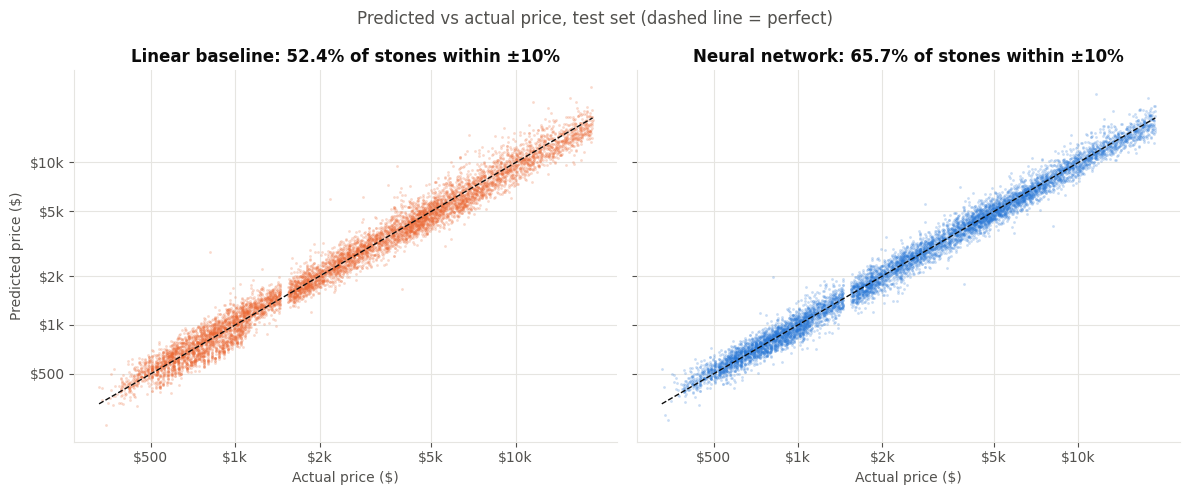

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, pred, name, color in [(axes[0], pred_base_test, 'Linear baseline', BASE_COLOR),
                              (axes[1], pred_ann_test, 'Neural network', ANN_COLOR)]:
    ax.scatter(price_test, pred, s=4, alpha=0.25, color=color, linewidths=0)
    lims = [price_test.min(), price_test.max()]
    ax.plot(lims, lims, color=INK, linestyle='--', linewidth=1)
    ax.set_xscale('log'); ax.set_yscale('log')
    w10 = np.mean(np.abs(pred - price_test) / price_test <= 0.10) * 100
    ax.set_title(f'{name}: {w10:.1f}% of stones within ±10%')
    ax.set_xlabel('Actual price ($)')
    ax.set_xticks([500, 1000, 2000, 5000, 10000], ['$500', '$1k', '$2k', '$5k', '$10k'])
    ax.set_yticks([500, 1000, 2000, 5000, 10000], ['$500', '$1k', '$2k', '$5k', '$10k'])
    ax.minorticks_off()
axes[0].set_ylabel('Predicted price ($)')
plt.suptitle('Predicted vs actual price, test set (dashed line = perfect)', color=INK2)
plt.tight_layout(); plt.show()

### 7.1 Where does the network help most?

Breaking the test set into price bands shows the typical % error in each. The linear model struggles most at **both ends of the market** (around 10-11% typical error for the cheapest and the most expensive stones), where the price curve bends most. The network holds a steady 5.5-6.3% in every band, so its quotes are equally trustworthy across the whole inventory. At the top end, each percentage point of error is also worth the most dollars.

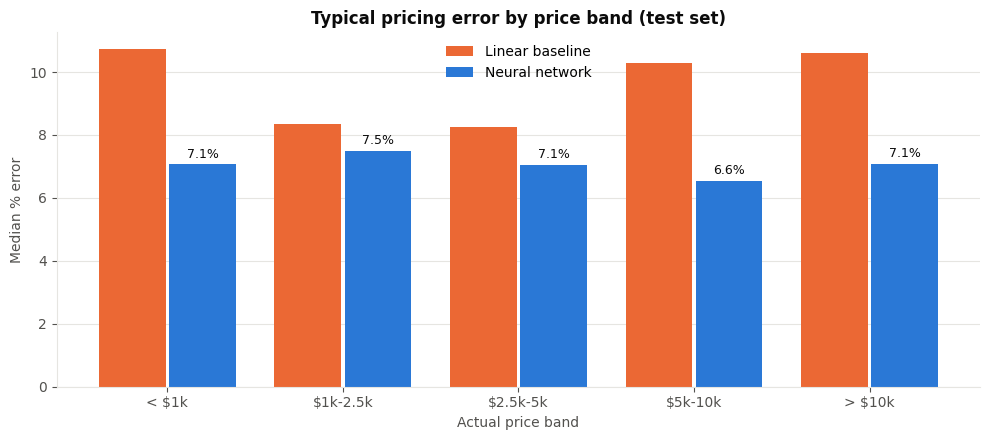

,Linear baseline,Neural network
band,,
< $1k,10.7,7.1
$1k-2.5k,8.3,7.5
$2.5k-5k,8.3,7.1
$5k-10k,10.3,6.6
> $10k,10.6,7.1


In [19]:
bands = [0, 1000, 2500, 5000, 10000, np.inf]
labels = ['< $1k', '$1k-2.5k', '$2.5k-5k', '$5k-10k', '> $10k']
band = pd.cut(price_test, bands, labels=labels)
pct_err = lambda p: np.abs(p - price_test) / price_test * 100
by_band = pd.DataFrame({'Linear baseline': pct_err(pred_base_test),
                        'Neural network': pct_err(pred_ann_test),
                        'band': band}).groupby('band', observed=True).median()

xpos = np.arange(len(labels)); w = 0.38
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(xpos - w/2 - 0.01, by_band['Linear baseline'], w, color=BASE_COLOR, label='Linear baseline')
ax.bar(xpos + w/2 + 0.01, by_band['Neural network'], w, color=ANN_COLOR, label='Neural network')
for i, v in enumerate(by_band['Neural network']):
    ax.text(i + w/2 + 0.01, v + 0.2, f'{v:.1f}%', ha='center', color=INK, fontsize=9)
ax.set_xticks(xpos, labels); ax.grid(axis='x', visible=False)
ax.set_ylabel('Median % error'); ax.set_xlabel('Actual price band')
ax.set_title('Typical pricing error by price band (test set)')
ax.legend()
plt.tight_layout(); plt.show()
by_band.round(1)

## 8. What did the network learn?

### 8.1 Which characteristics drive price?

**Permutation importance** (hand-made): shuffle one group of features across the test set, so it carries no information, and measure how much worse the pricing error gets. The bigger the jump, the more the model relies on that characteristic. Carat and the x/y/z dimensions are shuffled together as *Size* because they measure the same thing.

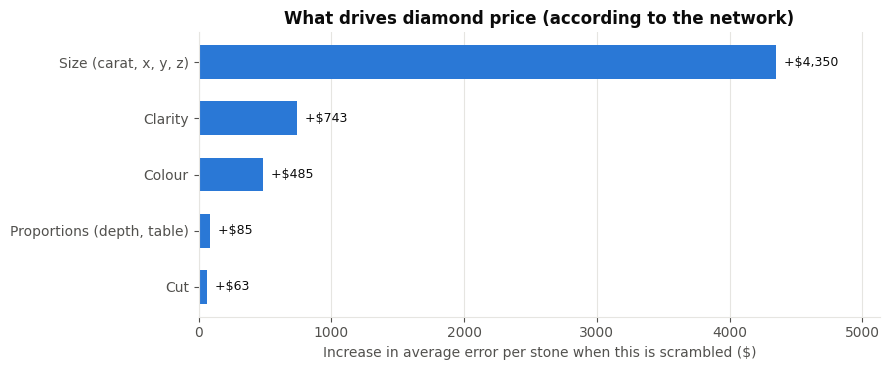

In [20]:
GROUPS = {
    'Size (carat, x, y, z)': ['carat', 'x', 'y', 'z'],
    'Clarity':               ['clarity_rank'],
    'Colour':                ['color_rank'],
    'Cut':                   ['cut_rank'],
    'Proportions (depth, table)': ['depth', 'table'],
}
perm_rng = np.random.default_rng(1)
base_mae = np.mean(np.abs(pred_ann_test - price_test))
importance = {}
for name, cols in GROUPS.items():
    idx = [FEATURES.index(c) for c in cols]
    increases = []
    for _ in range(5):
        Xp = X_test.copy()
        Xp[:, idx] = Xp[perm_rng.permutation(len(Xp))][:, idx]
        increases.append(np.mean(np.abs(to_dollars(model.predict(Xp)) - price_test)) - base_mae)
    importance[name] = np.mean(increases)
importance = pd.Series(importance).sort_values()

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.barh(importance.index, importance.values, color=BLUE, height=0.6)
for i, v in enumerate(importance.values):
    ax.text(v, i, f'  +${v:,.0f}', va='center', color=INK, fontsize=9)
ax.set_xlabel('Increase in average error per stone when this is scrambled ($)')
ax.set_title('What drives diamond price (according to the network)')
ax.grid(axis='y', visible=False)
ax.set_xlim(0, importance.max() * 1.18)
plt.tight_layout(); plt.show()

### 8.2 The nonlinear interaction the network discovered

A **"what-if" analysis:** take every real test stone, ask the network what it *would* be worth at different clarity grades (everything else unchanged), and average by size.

The curves are **not parallel**, and they show a visible step at 1.0 carat, the "magic size" premium seen in the raw data. Upgrading clarity adds a few hundred dollars to a small stone but thousands to a large one. A linear model on log-price is forced to apply the same percentage uplift at every size; the network learns from the data how the effect actually varies.

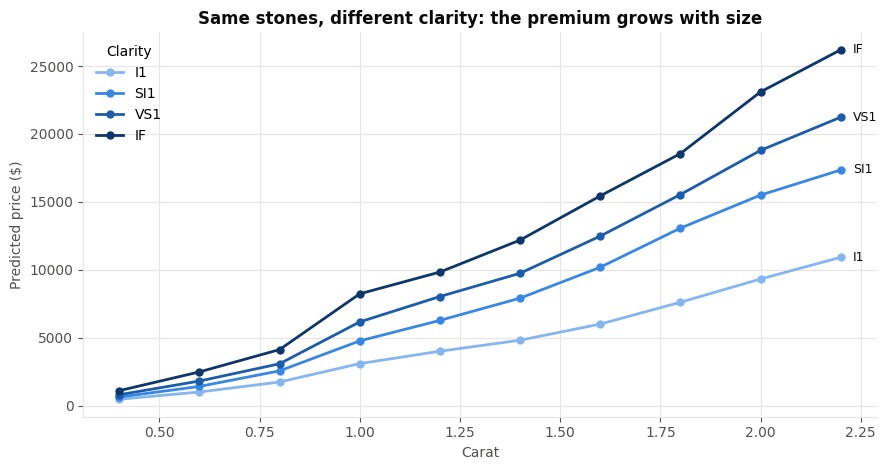

In [21]:
carat_bins = np.arange(0.3, 2.31, 0.2)
carat_mid = (carat_bins[:-1] + carat_bins[1:]) / 2
stone_bin = np.digitize(X[test_idx, 0], carat_bins) - 1
show = ['I1', 'SI1', 'VS1', 'IF']
ramp = ['#86b6ef', '#3987e5', '#1c5cab', '#0d366b']   # ordinal blue ramp: worse -> better

fig, ax = plt.subplots(figsize=(9, 4.8))
for grade, color in zip(show, ramp):
    X_what_if = X[test_idx].copy()
    X_what_if[:, FEATURES.index('clarity_rank')] = CLARITY_ORDER.index(grade)
    p = to_dollars(model.predict(x_scaler.transform(X_what_if)))
    curve = [np.median(p[stone_bin == b]) if np.any(stone_bin == b) else np.nan for b in range(len(carat_mid))]
    ax.plot(carat_mid, curve, color=color, linewidth=2, marker='o', markersize=5, label=grade)
    ax.text(carat_mid[-1] + 0.03, curve[-1], grade, color=INK, va='center', fontsize=9)
ax.set_xlabel('Carat'); ax.set_ylabel('Predicted price ($)')
ax.set_title('Same stones, different clarity: the premium grows with size')
ax.legend(title='Clarity', loc='upper left')
plt.tight_layout(); plt.show()

## 9. Putting it to work

### 9.1 Instant quote tool

A pricing clerk types a stone's grades and gets a price with an honest error band. If the exact dimensions are unknown, they are estimated from carat using a power-law fit on the training data.

In [22]:
# Estimate x, y, z from carat with a log-log least-squares fit (training data only)
log_carat = np.log(X[train_idx, 0])
dim_fits = {d: np.polyfit(log_carat, np.log(X[train_idx, FEATURES.index(d)]), 1) for d in ('x', 'y', 'z')}
typical_error = np.median(np.abs(pred_ann_test - price_test) / price_test)

def quote_price(carat, cut, color, clarity, depth=61.8, table=57.0):
    dims = {d: np.exp(np.polyval(fit, np.log(carat))) for d, fit in dim_fits.items()}
    row = np.array([[carat, CUT_ORDER.index(cut), COLOR_ORDER.index(color), CLARITY_ORDER.index(clarity),
                     depth, table, dims['x'], dims['y'], dims['z']]])
    p = to_dollars(model.predict(x_scaler.transform(row)))[0]
    return p, p * (1 - typical_error), p * (1 + typical_error)

examples = [(0.50, 'Ideal', 'G', 'VS1'), (1.00, 'Ideal', 'G', 'VS1'), (1.00, 'Premium', 'D', 'IF'),
            (1.00, 'Good', 'J', 'SI2'), (1.50, 'Very Good', 'F', 'VS2'), (2.00, 'Ideal', 'H', 'SI1')]
quotes = []
for c, cut, col, cla in examples:
    p, lo, hi = quote_price(c, cut, col, cla)
    quotes.append({'carat': c, 'cut': cut, 'colour': col, 'clarity': cla,
                   'quote': f'${p:,.0f}', 'typical range': f'${lo:,.0f} - ${hi:,.0f}'})
print(f'Typical error band: ±{typical_error * 100:.1f}% (median test-set error)')
pd.DataFrame(quotes)

Typical error band: ±7.1% (median test-set error)


,carat,cut,colour,clarity,quote,typical range
0,0.5,Ideal,G,VS1,"$1,531","$1,423 - $1,639"
1,1.0,Ideal,G,VS1,"$6,517","$6,057 - $6,977"
2,1.0,Premium,D,IF,"$12,973","$12,057 - $13,889"
3,1.0,Good,J,SI2,"$3,061","$2,845 - $3,277"
4,1.5,Very Good,F,VS2,"$12,161","$11,302 - $13,020"
5,2.0,Ideal,H,SI1,"$15,765","$14,652 - $16,879"


### 9.2 Mispricing audit list

Stones whose actual price is **more than 30% away** from the model's estimate are flagged for a human to review. A flag doesn't prove the price is wrong. It could be a data-entry error, a feature missing from this data (fluorescence, certificate, brand), or a genuine pricing mistake. Either way, it tells staff where to look first.

In [23]:
gap = (price_test - pred_ann_test) / pred_ann_test
audit = df.iloc[test_idx][['carat', 'cut', 'color', 'clarity', 'price']].copy()
audit['model_estimate'] = pred_ann_test.round(0)
audit['gap_%'] = (gap * 100).round(1)
flagged = audit[np.abs(gap) > 0.30].sort_values('gap_%', key=np.abs, ascending=False)

print(f'{len(flagged)} of {len(audit):,} test stones flagged ({len(flagged) / len(audit) * 100:.1f}%)')
print(f'  priced ABOVE model by >30%: {(flagged["gap_%"] > 0).sum()}   (may sit unsold)')
print(f'  priced BELOW model by >30%: {(flagged["gap_%"] < 0).sum()}   (possible lost margin)')
flagged.head(10)

112 of 8,065 test stones flagged (1.4%)
  priced ABOVE model by >30%: 83   (may sit unsold)
  priced BELOW model by >30%: 29   (possible lost margin)


,carat,cut,color,clarity,price,model_estimate,gap_%
5838,0.51,Fair,F,VVS2,3920,1796.0,118.2
19451,1.57,Fair,H,VS1,8133,4067.0,100.0
40597,0.41,Ideal,H,VS2,1163,710.0,63.8
50256,0.50,Very Good,G,VVS2,2260,1400.0,61.4
14534,1.03,Very Good,I,SI2,5884,3707.0,58.7
32991,0.34,Good,E,VS2,816,1965.0,-58.5
23475,3.00,Good,E,I1,11548,26255.0,-56.0
49738,0.50,Very Good,G,VVS1,2180,1404.0,55.3
47302,0.50,Ideal,G,SI1,1857,1205.0,54.1
3451,0.72,Ideal,I,VS2,3391,2243.0,51.2


### 9.3 Business impact on the test set

Adding up absolute pricing errors across every stone in the test set gives a direct, unextrapolated view of the difference between the two models.

In [24]:
total_base = np.sum(np.abs(pred_base_test - price_test))
total_ann  = np.sum(np.abs(pred_ann_test - price_test))
total_value = price_test.sum()
print(f'Test set: {len(price_test):,} diamonds worth ${total_value / 1e6:,.1f}M in total')
print(f'Total absolute pricing error, linear baseline: ${total_base / 1e6:,.2f}M ({total_base / total_value * 100:.1f}% of value)')
print(f'Total absolute pricing error, neural network:  ${total_ann / 1e6:,.2f}M ({total_ann / total_value * 100:.1f}% of value)')
print(f'Pricing error removed by the network:          ${(total_base - total_ann) / 1e6:,.2f}M ({(1 - total_ann / total_base) * 100:.0f}% less)')

Test set: 8,065 diamonds worth $31.9M in total
Total absolute pricing error, linear baseline: $3.80M (11.9% of value)
Total absolute pricing error, neural network:  $2.78M (8.7% of value)
Pricing error removed by the network:          $1.02M (27% less)


## 10. Save the trained model

The weights and scaler statistics are saved with NumPy, so the quote tool can be loaded elsewhere without retraining.

In [25]:
np.savez('diamond_pricing_model.npz',
         **{f'W{i}': l.W for i, l in enumerate(model.layers)},
         **{f'b{i}': l.b for i, l in enumerate(model.layers)},
         x_mean=x_scaler.mean_, x_std=x_scaler.std_, y_mean=y_scaler.mean_, y_std=y_scaler.std_)

# Reload into a fresh network and confirm predictions match exactly
saved = np.load('diamond_pricing_model.npz')
reloaded = Sequential([Dense(len(FEATURES), 64, 'relu', rng), Dense(64, 64, 'relu', rng),
                       Dense(64, 32, 'relu', rng), Dense(32, 1, 'linear', rng)])
reloaded.set_weights([(saved[f'W{i}'], saved[f'b{i}']) for i in range(4)])
print('Reloaded model matches:', np.allclose(reloaded.predict(X_test), model.predict(X_test)))

Reloaded model matches: True


## 11. Limitations and next steps

**Limitations**
- The prices are historical and not current market prices; a production model would retrain on the retailer's own recent sales.
- Important value drivers are missing from this data: fluorescence, certification lab, shape (all stones here are round), and lab-grown vs natural.
- The error band is a typical (median) error, not a formal prediction interval.

**Next steps**
- Retrain on live sales data and monitor error drift month by month.
- Add proper prediction intervals, e.g. by training an ensemble of networks with different seeds.
- Compare against gradient-boosted trees, a strong alternative for tabular data.
- Wrap `quote_price` in a small web app or API for pricing staff.

---
*Everything above (network, backpropagation, Adam, scaling, splitting, baseline and metrics) is implemented from scratch in NumPy.*